<p style="font-size: 20px;">
<b>Student Full Name:</b> Jasser Dhaouadi <br>
<b>Student ID:</b> U89818600 <br>
<b>Course:</b> Data Science Capstone - 1 <br>
<b>Semester:</b> Summer 2026 <br>
<b>Program:</b> OMDS <br>
<b>Boston University</b> 
</p>

# Week 5 - Support Vector Machines (SVM), the Kernel Trick, and Regularization

# Homework - Working On My Datasets

### Packages

In [37]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### IMPORTANT NOTE:

- In this notebook I am applying the Week 5 concepts to my datasets.

- The main Week 5 concepts are **Support Vector Machines, margin maximization, support vectors, feature scaling, kernels, and regularization through the parameter** `C`

- Because the target variables of 2 datasets (diabetes and obesity) has multiple classes, the SVM models are applied as multiclass classifiers. 

- **Linear SVMs** are trained on the full dataset, while **kernel SVMs** are trained on a balanced sample because **full nonlinear SVM training is computationally expensive** on more than 200,000 training rows

## Dataset 1: CDC Diabetes Health Indicators  (sourced from BRFSS) 

#### [Dataset 1] | *1- Load the dataset*

In [2]:
diabetes_path = "diabetes_012_health_indicators_BRFSS2015.csv"


df_diabetes = pd.read_csv(diabetes_path)

print("Dataset shape:", df_diabetes.shape)
display(df_diabetes.head())

target = "Diabetes_012"

class_counts = df_diabetes[target].value_counts().sort_index()
class_percent = (class_counts / len(df_diabetes) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


,Class Count,Percent
Diabetes_012,,
0.0,213703,84.24
1.0,4631,1.83
2.0,35346,13.93



- The **target** is highly **imbalanced**:
    - Class 0 dominates the dataset
    - while class 1 is very rare

- Because of this, accuracy alone is not enough: Balanced accuracy, macro F1, and multiclass ROC AUC are used to better evaluate the models.

#### [Dataset 1] | *2- Train-test split*

In [3]:
X = df_diabetes.drop(columns=[target])
y = df_diabetes[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (202944, 21)
Testing shape: (50736, 21)


,Train Class Count
Diabetes_012,
0,170962
1,3705
2,28277


,Test Class Count
Diabetes_012,
0,42741
1,926
2,7069


- The data was split into training and testing sets using **stratification**.


| Split | Shape |
|---|---:|
| Training | (202,944, 21) |
| Testing | (50,736, 21) |


- **Stratification** is important because the prediabetes class is very small
    - This keeps the **class distribution similar in both the training and testing sets**.

#### [Dataset 1] | *3- Investigate feature scales*

In [4]:
scale_summary = pd.DataFrame({
    "Feature": X.columns,
    "Minimum": X.min().values,
    "Maximum": X.max().values,
    "Mean": X.mean().values,
    "Std": X.std().values
})

scale_summary["Range"] = scale_summary["Maximum"] - scale_summary["Minimum"]

display(
    scale_summary
    .sort_values("Range", ascending=False)
    .head(10)
)

,Feature,Minimum,Maximum,Mean,Std,Range
3,BMI,12.0,98.0,28.382364,6.608694,86.0
14,MentHlth,0.0,30.0,3.184772,7.412847,30.0
15,PhysHlth,0.0,30.0,4.242081,8.717951,30.0
18,Age,1.0,13.0,8.032119,3.054220,12.0
20,Income,1.0,8.0,6.053875,2.071148,7.0
19,Education,1.0,6.0,5.050434,0.985774,5.0
13,GenHlth,1.0,5.0,2.511392,1.068477,4.0
1,HighChol,0.0,1.0,0.424121,0.494210,1.0
0,HighBP,0.0,1.0,0.429001,0.494934,1.0
4,Smoker,0.0,1.0,0.443169,0.496761,1.0


- The **feature-scale summary** showed that the largest feature ranges were:

| Feature | Minimum | Maximum | Mean | Std | Range |
|---|---:|---:|---:|---:|---:|
| BMI | 12.0 | 98.0 | 28.382 | 6.609 | 86.0 |
| MentHlth | 0.0 | 30.0 | 3.185 | 7.413 | 30.0 |
| PhysHlth | 0.0 | 30.0 | 4.242 | 8.718 | 30.0 |
| Age | 1.0 | 13.0 | 8.032 | 3.054 | 12.0 |
| Income | 1.0 | 8.0 | 6.054 | 2.071 | 7.0 |
| Education | 1.0 | 6.0 | 5.050 | 0.986 | 5.0 |
| GenHlth | 1.0 | 5.0 | 2.511 | 1.068 | 4.0 |
| HighChol | 0.0 | 1.0 | 0.424 | 0.494 | 1.0 |
| HighBP | 0.0 | 1.0 | 0.429 | 0.495 | 1.0 |
| Smoker | 0.0 | 1.0 | 0.443 | 0.497 | 1.0 |

- This matters for **SVMs** because **SVMs** use **distances** and **margins**
    - If one feature has a much larger scale, it can dominate the margin calculation
    - Therefore, *standardization* is important **before training SVM models**

#### [Dataset 1] | *4- Visualize feature ranges*

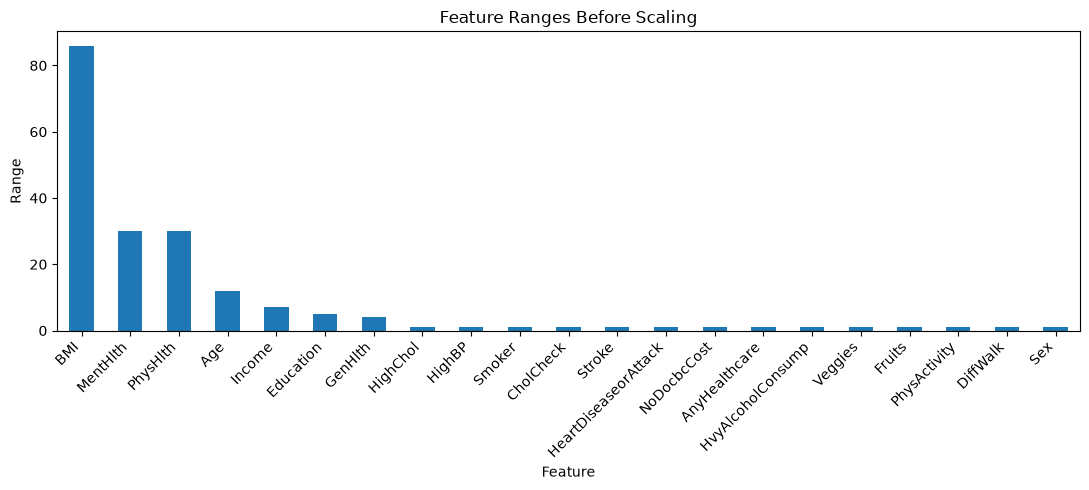

In [5]:
scale_summary.sort_values("Range", ascending=False).plot(
    x="Feature",
    y="Range",
    kind="bar",
    figsize=(11, 5),
    legend=False
)

plt.title("Feature Ranges Before Scaling")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- The **feature-range plot** shows that the diabetes predictors are **not** on the same scale

    - `BMI`, `MentHlth`, and `PhysHlth` have much larger ranges than binary predictors such as `HighBP`, `Smoker`, or `Stroke`
    
- **SVMs** should generally be **trained after feature scaling** because the margin depends on the geometry of the feature space


#### [Dataset 1] | *5- Define evaluation helper functions*

In [6]:
def macro_ovr_auc_from_scores(y_true, scores, classes):
    auc_values = []
    y_array = np.asarray(y_true)
    
    for class_index, class_label in enumerate(classes):
        binary_target = (y_array == class_label).astype(int)
        class_scores = scores[:, class_index]
        auc_values.append(
            roc_auc_score(binary_target, class_scores)
        )
    
    return float(np.mean(auc_values))


def evaluate_svm_model(model_name, model, X_train_data, X_test_data):
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = model.predict(X_test_data)
    decision_scores = model.decision_function(X_test_data)
    
    if decision_scores.ndim == 1:
        decision_scores = np.vstack([
            -decision_scores,
            decision_scores
        ]).T
    
    svm_step = list(model.named_steps.values())[-1]
    classes = svm_step.classes_
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": macro_ovr_auc_from_scores(
            y_test,
            decision_scores,
            classes
        ),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, decision_scores, model

- We define **helper functions** for **evaluating SVM models**

- **SVMs** do not naturally produce probabilities like **logistic regression**. Instead, they produce **decision scores**
    - For **ROC AUC**, we use **one-vs-rest decision scores for each class**

- The **metrics** include
    - **accuracy**
    - **balanced accuracy**
    - **macro F1**
    - **weighted F1**
    - **macro one-vs-rest ROC AUC**

#### [Dataset 1] | *6- Compare linear SVM with and without standardization*

In [7]:
linear_svm_models = {
    "Linear SVM without scaling": Pipeline(
        steps=[
            ("svm", LinearSVC(
                C=1.0,
                class_weight="balanced",
                dual=False,
                max_iter=5000,
                random_state=42
            ))
        ]
    ),
    "Linear SVM with standardization": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(
                C=1.0,
                class_weight="balanced",
                dual=False,
                max_iter=5000,
                random_state=42
            ))
        ]
    )
}

linear_svm_results = []
linear_svm_predictions = {}
linear_svm_scores = {}
linear_svm_fitted_models = {}

for model_name, model in linear_svm_models.items():
    metrics, predictions, scores, fitted_model = evaluate_svm_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    linear_svm_results.append(metrics)
    linear_svm_predictions[model_name] = predictions
    linear_svm_scores[model_name] = scores
    linear_svm_fitted_models[model_name] = fitted_model

linear_svm_results_df = pd.DataFrame(linear_svm_results)

display(linear_svm_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Fit Time Seconds
0,Linear SVM without scaling,0.818551,0.457181,0.446714,0.815897,0.781118,3.940693
1,Linear SVM with standardization,0.818531,0.457173,0.446700,0.815882,0.781119,0.855981


- The **linear SVM scaling comparison**:

    - The **predictive scores** are almost identical, but **standardization** reduced **fit time** substantially.

- **SVMs** are sensitive to **feature scale** because the margin is based on distances. 

    - In this execution, **scaling** did not materially change the final decision boundary performance, but it made training much faster.

#### [Dataset 1] | *7- Visualize linear SVM scaling comparison*

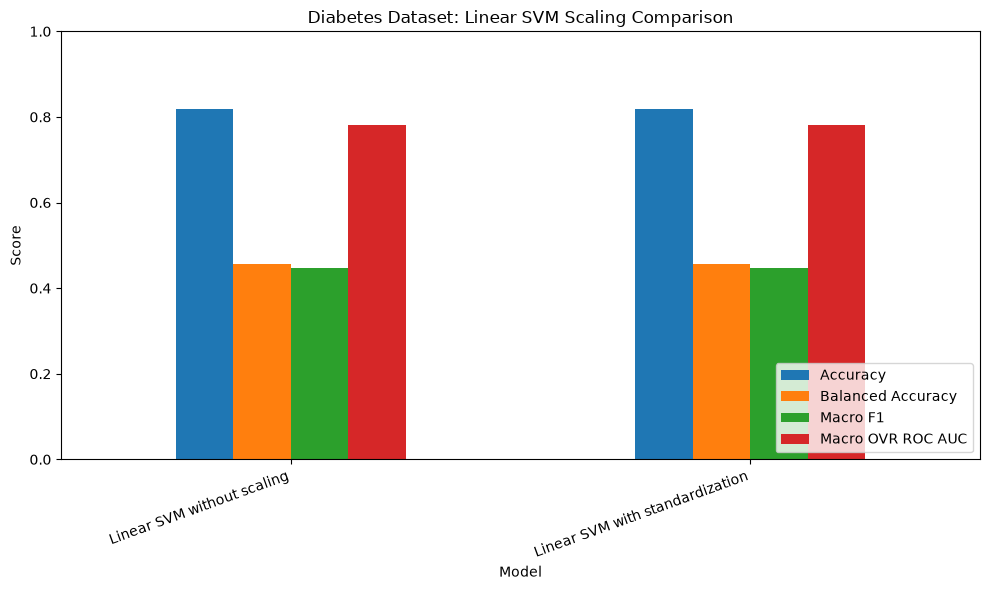

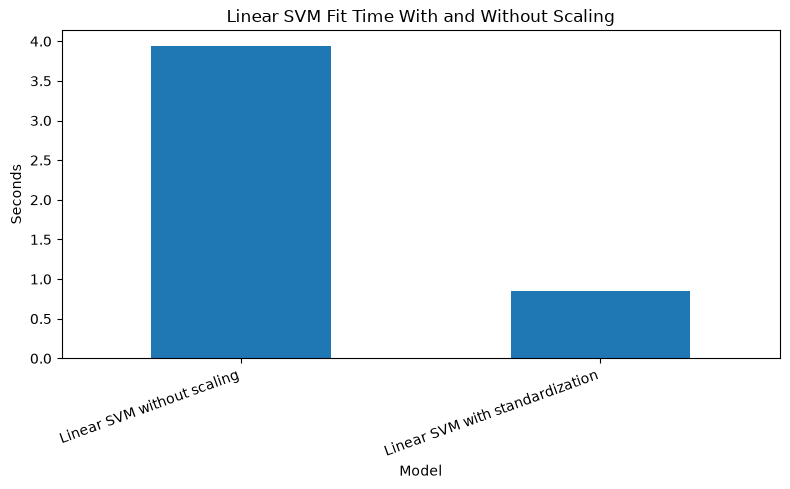

In [8]:
linear_svm_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Diabetes Dataset: Linear SVM Scaling Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

linear_svm_results_df.set_index("Model")[
    ["Fit Time Seconds"]
].plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Linear SVM Fit Time With and Without Scaling")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- The first plot shows that the two **linear SVM models** performed almost the same

- The second plot shows the practical benefit of **standardization**:
    - **Training time** dropped from about 4 seconds **without scaling** to about 1 second **with scaling**
    - **scaled features** make **margin-based optimization more stable**.

#### [Dataset 1] | *8- Compare SVM regularization parameter C*

In [9]:
c_results = []
c_predictions = {}
c_scores = {}
c_fitted_models = {}

for c_value in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    model_name = f"Linear SVM with C={c_value}"
    
    svm_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(
                C=c_value,
                class_weight="balanced",
                dual=False,
                max_iter=5000,
                random_state=42
            ))
        ]
    )
    
    metrics, predictions, scores, fitted_model = evaluate_svm_model(
        model_name,
        svm_model,
        X_train,
        X_test
    )
    
    svm_step = fitted_model.named_steps["svm"]
    coefficient_norms = np.linalg.norm(svm_step.coef_, axis=1)
    margin_proxy = 1 / coefficient_norms
    
    metrics["Mean Coefficient Norm"] = coefficient_norms.mean()
    metrics["Mean Margin Proxy"] = margin_proxy.mean()
    metrics["Iterations"] = int(svm_step.n_iter_)
    
    c_results.append(metrics)
    c_predictions[model_name] = predictions
    c_scores[model_name] = scores
    c_fitted_models[model_name] = fitted_model

c_results_df = pd.DataFrame(c_results)

display(c_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Fit Time Seconds,Mean Coefficient Norm,Mean Margin Proxy,Iterations
0,Linear SVM with C=0.0001,0.817565,0.457264,0.446291,0.815236,0.780972,0.852033,0.282507,3.750607,5
1,Linear SVM with C=0.001,0.818709,0.457480,0.446970,0.816052,0.781110,0.864170,0.298818,3.576860,5
2,Linear SVM with C=0.01,0.818551,0.457221,0.446737,0.815905,0.781118,0.851002,0.300761,3.557824,5
3,Linear SVM with C=0.1,0.818551,0.457181,0.446714,0.815897,0.781119,1.023739,0.300960,3.555900,5
4,Linear SVM with C=1,0.818531,0.457173,0.446700,0.815882,0.781119,1.030021,0.300980,3.555708,5
5,Linear SVM with C=10,0.818531,0.457173,0.446700,0.815882,0.781119,1.032332,0.300982,3.555688,5



- The best **macro F1** was achieved with `C=0.001`, but the differences across `C` values were very small.

- The margin proxy shows the Week 5 regularization idea clearly:
    - The smallest `C`, 0.0001, had the largest margin proxy. 
    - This matches the lesson: smaller `C` allows a larger margin, while larger `C` focuses more on classifying training points correctly.

#### [Dataset 1] | *9- Visualize effect of C*

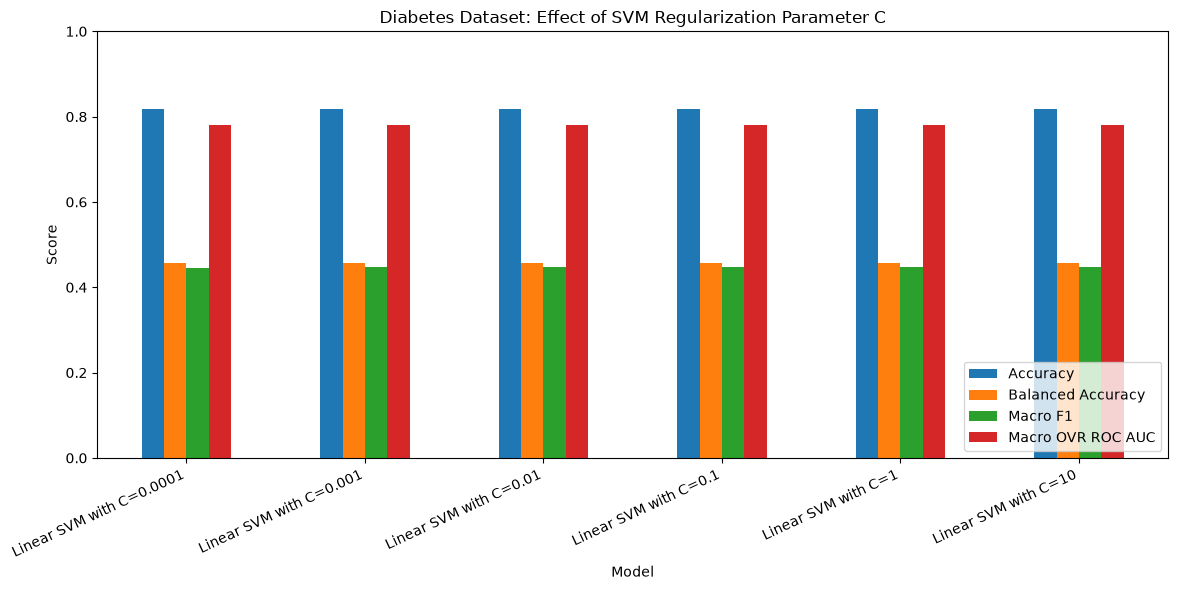

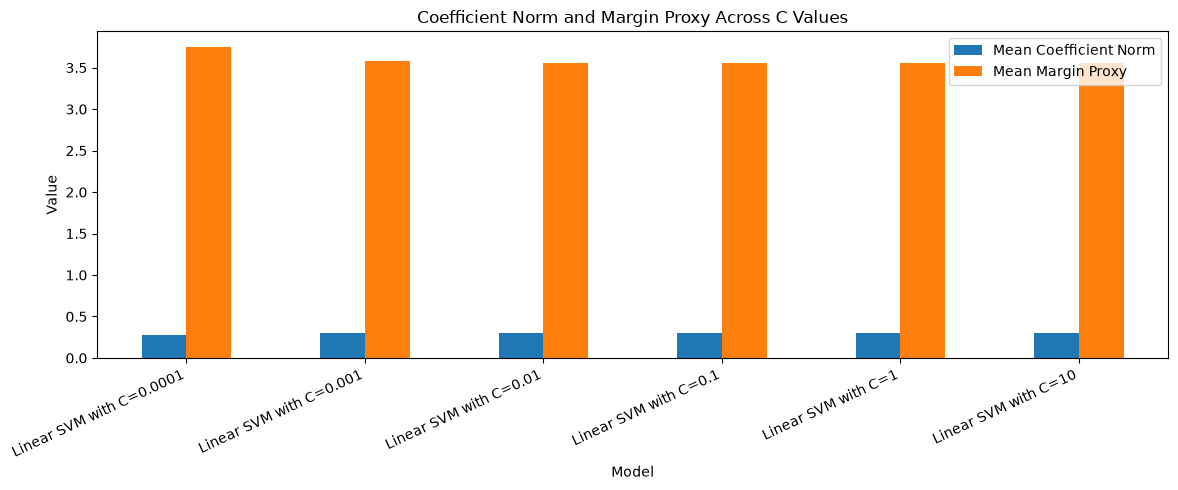

In [10]:
c_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Diabetes Dataset: Effect of SVM Regularization Parameter C")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

c_results_df.set_index("Model")[
    ["Mean Coefficient Norm", "Mean Margin Proxy"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Coefficient Norm and Margin Proxy Across C Values")
plt.ylabel("Value")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- The **first plot** shows that changing `C` had only a small effect on predictive performance

- The **second plot** shows the margin trade-off
    - Smaller `C` values produce smaller coefficient norms and larger margin proxies
    - Larger `C` values produce slightly larger coefficient norms and smaller margin proxies

- **Regularization**: `C` controls the trade-off between a wider margin and stricter classification of training points

#### [Dataset 1] | *10- Create balanced sample for kernel SVMs*

In [11]:
train_for_kernel = X_train.copy()
train_for_kernel["target"] = y_train.values

balanced_parts = []

for class_label in sorted(train_for_kernel["target"].unique()):
    class_subset = train_for_kernel[
        train_for_kernel["target"] == class_label
    ]
    
    balanced_parts.append(
        class_subset.sample(
            n=2000,
            replace=len(class_subset) < 2000,
            random_state=42
        )
    )

balanced_kernel_train = (
    pd.concat(balanced_parts)
    .sample(frac=1, random_state=42)
)

X_kernel_train = balanced_kernel_train.drop(columns=["target"])
y_kernel_train = balanced_kernel_train["target"].astype(int)

display(y_kernel_train.value_counts().sort_index().to_frame("Kernel Training Count"))

,Kernel Training Count
target,
0,2000
1,2000
2,2000


- A **balanced sample was created for kernel SVM training**

- The sample contained:

| Class | Kernel Training Count |
|---:|---:|
| 0 | 2,000 |
| 1 | 2,000 |
| 2 | 2,000 |

- **Kernel SVMs** are much more **computationally expensive** than **linear SVMs**, especially on a **large dataset**

    - Therefore, the **kernel models** are trained on a balanced **6,000-row sample** but **evaluated** on the **full test** set

#### [Dataset 1] | *11- Define kernel SVM evaluation function*

In [12]:
def evaluate_kernel_svm(model_name, kernel, c_value=1.0, degree=3, gamma="scale"):
    kernel_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel=kernel,
                C=c_value,
                degree=degree,
                gamma=gamma,
                class_weight="balanced",
                decision_function_shape="ovr",
                random_state=42
            ))
        ]
    )
    
    start_time = time.time()
    
    kernel_model.fit(X_kernel_train, y_kernel_train)
    
    fit_time = time.time() - start_time
    
    predictions = kernel_model.predict(X_test)
    decision_scores = kernel_model.decision_function(X_test)
    
    svm_step = kernel_model.named_steps["svm"]
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": macro_ovr_auc_from_scores(
            y_test,
            decision_scores,
            svm_step.classes_
        ),
        "Support Vectors": int(svm_step.n_support_.sum()),
        "Class 0 SVs": int(svm_step.n_support_[0]),
        "Class 1 SVs": int(svm_step.n_support_[1]),
        "Class 2 SVs": int(svm_step.n_support_[2]),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, decision_scores, kernel_model

- This helper function **trains kernel SVM models** and **reports** both **performance metrics** and **support-vector counts**

- The **support-vector** count is important because :

    - **support vectors** are the observations closest to the decision boundary
    - They are the points that most directly influence the **margin** and the **final separating boundary**

#### [Dataset 1] | *12- Compare linear, polynomial, and RBF kernels*

In [13]:
kernel_specs = [
    ("Kernel SVM: linear kernel", "linear", 1.0, 3, "scale"),
    ("Kernel SVM: polynomial degree 2", "poly", 1.0, 2, "scale"),
    ("Kernel SVM: RBF kernel", "rbf", 1.0, 3, "scale")
]

kernel_results = []
kernel_predictions = {}
kernel_scores = {}
kernel_fitted_models = {}

for model_name, kernel_name, c_value, degree, gamma in kernel_specs:
    metrics, predictions, scores, fitted_model = evaluate_kernel_svm(
        model_name=model_name,
        kernel=kernel_name,
        c_value=c_value,
        degree=degree,
        gamma=gamma
    )
    
    kernel_results.append(metrics)
    kernel_predictions[model_name] = predictions
    kernel_scores[model_name] = scores
    kernel_fitted_models[model_name] = fitted_model

kernel_results_df = pd.DataFrame(kernel_results)

display(kernel_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Support Vectors,Class 0 SVs,Class 1 SVs,Class 2 SVs,Fit Time Seconds
0,Kernel SVM: linear kernel,0.627740,0.519857,0.417469,0.704936,0.757025,5151,1397,1994,1760,1.093954
1,Kernel SVM: polynomial degree 2,0.519414,0.471307,0.362948,0.625850,0.689757,5391,1620,1936,1835,1.788907
2,Kernel SVM: RBF kernel,0.599752,0.504785,0.404752,0.687957,0.739854,5228,1437,1983,1808,0.693256


- The **kernel SVM comparison** was:

| Model | Accuracy | Balanced Accuracy | Macro F1 | Weighted F1 | Macro OVR ROC AUC | Support Vectors |
|---|---:|---:|---:|---:|---:|---:|
| Kernel SVM: linear kernel | 0.627740 | 0.519857 | 0.417469 | 0.704936 | 0.757025 | 5,151 |
| Kernel SVM: polynomial degree 2 | 0.519414 | 0.471307 | 0.362948 | 0.625850 | 0.689757 | 5,391 |
| Kernel SVM: RBF kernel | 0.599752 | 0.504785 | 0.404752 | 0.687957 | 0.739854 | 5,228 |

- The **linear kernel** performed best among the three kernel models by **balanced accuracy** and **macro F1**

- The **polynomial and RBF kernels** did not improve performance on this dataset 
    - This suggests that the** nonlinear boundaries** introduced by the **kernel trick** did not provide a strong advantage here, at least with this **balanced training sample** and these **default kernel settings**

- A large number of observations became **support vectors**, especially for **class 1**
    - This indicates that the **decision boundary is difficult**, which makes sense because prediabetes is rare and overlaps with the other classes

#### [Dataset 1] | *13- Visualize kernel SVM comparison*

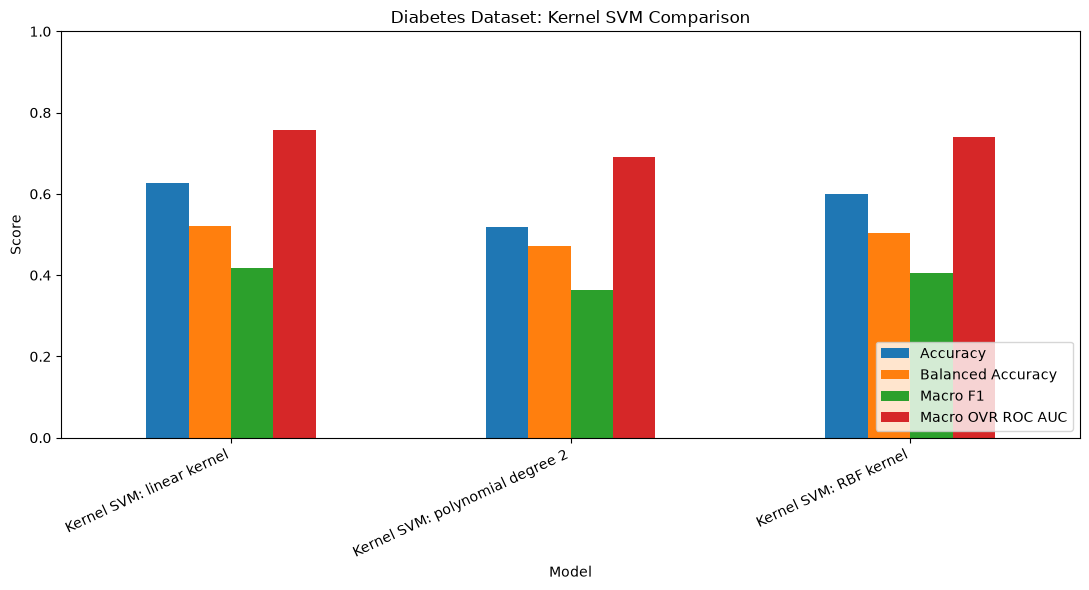

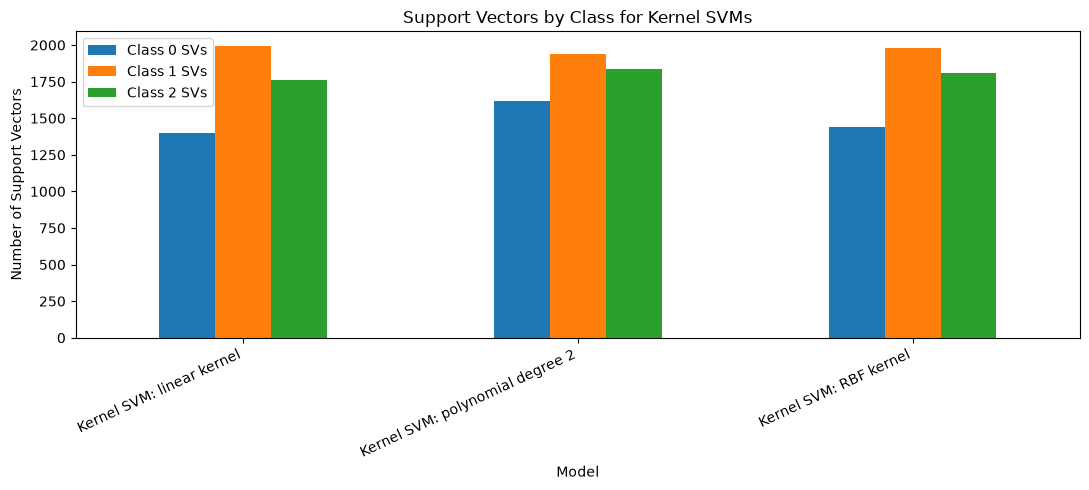

In [14]:
kernel_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Diabetes Dataset: Kernel SVM Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

kernel_results_df.set_index("Model")[
    ["Class 0 SVs", "Class 1 SVs", "Class 2 SVs"]
].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Support Vectors by Class for Kernel SVMs")
plt.ylabel("Number of Support Vectors")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- The **first plot** shows that the **linear kernel** was the strongest kernel model in this execution

- The **second plot** shows the **number of support vectors by class**:
    -  Most **class 1 observations** in the **balanced kernel sample** became **support vectors**
    - This means many **prediabetes** samples were close to the boundary and helped define the **margin**

- This is consistent with the earlier results across weeks: **class 1 is the hardest class to separate**

#### [Dataset 1] | *14- Final model comparison*

In [15]:
best_c_model_name = c_results_df.loc[
    c_results_df["Macro F1"].idxmax(),
    "Model"
]

best_c_row = c_results_df[
    c_results_df["Model"] == best_c_model_name
].copy()

final_comparison = pd.concat([
    linear_svm_results_df,
    best_c_row[[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1",
        "Macro OVR ROC AUC",
        "Fit Time Seconds"
    ]],
    kernel_results_df[[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1",
        "Macro OVR ROC AUC",
        "Fit Time Seconds"
    ]]
], ignore_index=True)

display(final_comparison)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Fit Time Seconds
0,Linear SVM without scaling,0.818551,0.457181,0.446714,0.815897,0.781118,3.940693
1,Linear SVM with standardization,0.818531,0.457173,0.446700,0.815882,0.781119,0.855981
2,Linear SVM with C=0.001,0.818709,0.457480,0.446970,0.816052,0.781110,0.864170
3,Kernel SVM: linear kernel,0.627740,0.519857,0.417469,0.704936,0.757025,1.093954
4,Kernel SVM: polynomial degree 2,0.519414,0.471307,0.362948,0.625850,0.689757,1.788907
5,Kernel SVM: RBF kernel,0.599752,0.504785,0.404752,0.687957,0.739854,0.693256



- The **best model by macro F1** was the **standardized linear SVM** with `C=0.001`.

- The **kernel SVM** with a **linear kernel** had the **best balanced accuracy**, but it had **lower macro F1 and lower overall accuracy**. 

- The **polynomial and RBF kernels** did not outperform the **linear SVM models**.

- For this diabetes dataset, the **linear SVM** approach was more **reliable** than the **nonlinear** kernel models

#### [Dataset 1] | *15- Classification report for best SVM model*

In [16]:
best_model_name = best_c_model_name
best_predictions = c_predictions[best_model_name]

print("Best SVM model by Macro F1:", best_model_name)

print(classification_report(
    y_test,
    best_predictions,
    digits=3,
    zero_division=0
))

best_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_predictions),
    index=["Actual 0", "Actual 1", "Actual 2"],
    columns=["Predicted 0", "Predicted 1", "Predicted 2"]
)

display(best_confusion)

Best SVM model by Macro F1: Linear SVM with C=0.001
              precision    recall  f1-score   support

           0      0.898     0.893     0.896     42741
           1      0.069     0.002     0.004       926
           2      0.410     0.477     0.441      7069

    accuracy                          0.819     50736
   macro avg      0.459     0.457     0.447     50736
weighted avg      0.815     0.819     0.816     50736



,Predicted 0,Predicted 1,Predicted 2
Actual 0,38161,21,4559
Actual 1,623,2,301
Actual 2,3688,6,3375


- The **best SVM model by macro F1** was:

    - **Linear SVM with C=0.001**

- The model performed well on **class 0** and moderately on **class 2**, but it struggled severely with **class 1**. It correctly identified only 2 of the 926 prediabetes cases.

- This confirms that the main challenge is not just the **classifier type**. The **rare class** is difficult to separate from the other two classes, even with a **margin-based SVM**.

#### [Dataset 1] | *16- Summary*


- The strongest **SVM model** by **macro F1** was the **standardized linear SVM** with `C=0.001`

    - **Standardization** reduced **training time**, supporting the importance of **feature scaling** for **SVMs**.
    
    - Changing `C` had only a small effect on performance, but the **margin proxy** showed the expected pattern: smaller `C` produced a larger **margin proxy**

- The **kernel trick** did not improve performance for this dataset. The **linear kernel** was stronger than both the **polynomial** and **RBF kernels** in this execution

- The **main takeaway** is that **SVMs** can be applied effectively to this dataset, but the prediabetes class remains very difficult to classify because it is rare and overlaps with the no-diabetes and diabetes groups

## Dataset 2: Obesity Levels

#### [Dataset 2] | *1- Load preprocessed obesity dataset*

In [17]:
obesity_path = "obesity_preprocessed_wk1.csv"


df_obesity_model = pd.read_csv(obesity_path)

print("Dataset shape:", df_obesity_model.shape)
display(df_obesity_model.head())

target = "NObeyesdad"

class_counts = df_obesity_model[target].value_counts()
class_percent = (class_counts / len(df_obesity_model) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (2111, 24)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,0,1,...,0,0,0,0,1,0,0,1,0,Normal_Weight
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,0,1,...,1,1,0,1,0,0,0,1,0,Normal_Weight
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,1,1,...,0,0,1,0,0,0,0,1,0,Normal_Weight
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,1,0,...,0,0,1,0,0,0,0,0,1,Overweight_Level_I
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,1,0,...,0,0,0,1,0,0,0,1,0,Overweight_Level_II


,Class Count,Percent
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


- The executed dataset shape was:

| Rows | Columns |
|---:|---:|
| 2,111 | 24 |


- There are **23** predictor columns and one target column, `NObeyesdad`.

- The target class distribution was:

| Class | Count |
|---|---:|
| Obesity_Type_I | 351 |
| Obesity_Type_III | 324 |
| Obesity_Type_II | 297 |
| Overweight_Level_I | 290 |
| Overweight_Level_II | 290 |
| Normal_Weight | 287 |
| Insufficient_Weight | 272 |

- The classes are **fairly balanced** compared with the diabetes dataset, so accuracy is more meaningful here. However, macro F1 and balanced accuracy are still useful because this is a multiclass classification problem.

#### [Dataset 2] | *2- Train-test split*

In [18]:
X = df_obesity_model.drop(columns=[target])
y = df_obesity_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().to_frame("Train Class Count"))
display(y_test.value_counts().to_frame("Test Class Count"))

Training shape: (1688, 23)
Testing shape: (423, 23)


,Train Class Count
NObeyesdad,
Obesity_Type_I,281
Obesity_Type_III,259
Obesity_Type_II,237
Overweight_Level_I,232
Overweight_Level_II,232
Normal_Weight,229
Insufficient_Weight,218


,Test Class Count
NObeyesdad,
Obesity_Type_I,70
Obesity_Type_III,65
Obesity_Type_II,60
Normal_Weight,58
Overweight_Level_II,58
Overweight_Level_I,58
Insufficient_Weight,54


- The data was split into training and testing sets using **stratification**

- The **split** was:

| Split | Shape |
|---|---:|
| Training | (1,688, 23) |
| Testing | (423, 23) |

- The **test set** kept all **seven obesity classes represented**:

| Class | Test Count |
|---|---:|
| Obesity_Type_I | 70 |
| Obesity_Type_III | 65 |
| Obesity_Type_II | 60 |
| Normal_Weight | 58 |
| Overweight_Level_II | 58 |
| Overweight_Level_I | 58 |
| Insufficient_Weight | 54 |

- **Stratification** is important because the **SVM** should be evaluated fairly across **all obesity categories**

#### [Dataset 2] | *3- Investigate feature scales*

In [19]:
scale_summary = pd.DataFrame({
    "Feature": X.columns,
    "Minimum": X.min().values,
    "Maximum": X.max().values,
    "Mean": X.mean().values,
    "Std": X.std().values
})

scale_summary["Range"] = scale_summary["Maximum"] - scale_summary["Minimum"]

display(
    scale_summary
    .sort_values("Range", ascending=False)
    .head(10)
)

,Feature,Minimum,Maximum,Mean,Std,Range
2,Weight,39.0,173.0,86.586058,26.191172,134.0
0,Age,14.0,61.0,24.312600,6.345968,47.0
4,NCP,1.0,4.0,2.685628,0.778039,3.0
6,FAF,0.0,3.0,1.010298,0.850592,3.0
3,FCVC,1.0,3.0,2.419043,0.533927,2.0
5,CH2O,1.0,3.0,2.008011,0.612953,2.0
7,TUE,0.0,2.0,0.657866,0.608927,2.0
15,SCC_yes,0.0,1.0,0.045476,0.208395,1.0
8,Gender_Male,0.0,1.0,0.505921,0.500083,1.0
9,family_history_with_overweight_yes,0.0,1.0,0.817622,0.386247,1.0


The **feature-scale summary** showed that the **largest feature ranges** were:

| Feature | Minimum | Maximum | Mean | Std | Range |
|---|---:|---:|---:|---:|---:|
| Weight | 39.0 | 173.0 | 86.586 | 26.191 | 134.0 |
| Age | 14.0 | 61.0 | 24.313 | 6.346 | 47.0 |
| NCP | 1.0 | 4.0 | 2.686 | 0.778 | 3.0 |
| FAF | 0.0 | 3.0 | 1.010 | 0.851 | 3.0 |
| FCVC | 1.0 | 3.0 | 2.419 | 0.534 | 2.0 |
| CH2O | 1.0 | 3.0 | 2.008 | 0.613 | 2.0 |
| TUE | 0.0 | 2.0 | 0.658 | 0.609 | 2.0 |
| SCC_yes | 0.0 | 1.0 | 0.045 | 0.208 | 1.0 |
| Gender_Male | 0.0 | 1.0 | 0.506 | 0.500 | 1.0 |
| family_history_with_overweight_yes | 0.0 | 1.0 | 0.818 | 0.386 | 1.0 |

- This matters for **SVMs** because **SVMs** depend on **distances**, **margins**, and **decision boundaries**. 
    - If one feature has a much larger scale, such as `Weight`, it can dominate the geometry of the model. 
    - Therefore, **feature scaling** is especially important before using **SVMs**.

#### [Dataset 2] | *4- Visualize feature ranges*

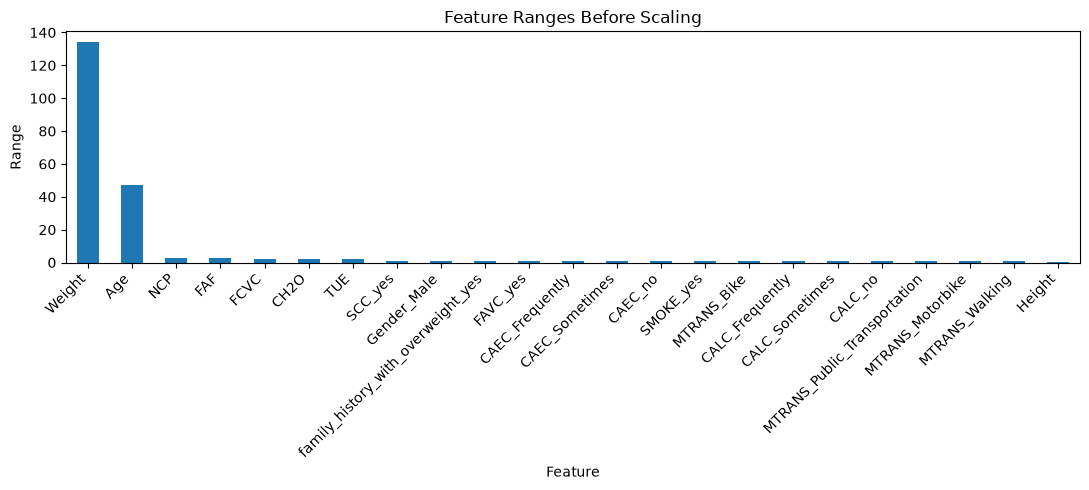

In [20]:
scale_summary.sort_values("Range", ascending=False).plot(
    x="Feature",
    y="Range",
    kind="bar",
    figsize=(11, 5),
    legend=False
)

plt.title("Feature Ranges Before Scaling")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- The **feature-range plot** shows that the **obesity predictors** are not on the same scale.

    - `Weight` has the largest range, followed by `Age`. 
    - Many **one-hot encoded** variables have a range of only 1. 
    
- **SVMs** should generally be **trained after feature scaling** because the margin depends on the feature-space geometry

#### [Dataset 2] | *5- Define evaluation helper functions*

In [21]:
def macro_ovr_auc_from_scores(y_true, scores, classes):
    auc_values = []
    y_array = np.asarray(y_true)
    
    for class_index, class_label in enumerate(classes):
        binary_target = (y_array == class_label).astype(int)
        class_scores = scores[:, class_index]
        
        auc_values.append(
            roc_auc_score(binary_target, class_scores)
        )
    
    return float(np.mean(auc_values))


def evaluate_svm_model(model_name, model, X_train_data, X_test_data):
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = model.predict(X_test_data)
    decision_scores = model.decision_function(X_test_data)
    
    if decision_scores.ndim == 1:
        decision_scores = np.vstack([
            -decision_scores,
            decision_scores
        ]).T
    
    svm_step = list(model.named_steps.values())[-1]
    classes = svm_step.classes_
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": macro_ovr_auc_from_scores(
            y_test,
            decision_scores,
            classes
        ),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, decision_scores, model

- We define **helper functions for evaluating SVM models**

- **SVMs** do not naturally produce **probabilities** in the same way **logistic regression** does. 
- Instead, they produce **decision scores**. These **decision score**s are used to calculate **multiclass one-vs-rest ROC AUC**.

- The metrics used are **accuracy**, **balanced accuracy**, **macro F1**, **weighted F1**, **macro ROC AUC**, and **fit time**.

#### [Dataset 2] | *6- Compare linear SVM with and without standardization*

In [22]:
linear_svm_models = {
    "Linear SVM without scaling": Pipeline(
        steps=[
            ("svm", LinearSVC(
                C=1.0,
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=42
            ))
        ]
    ),
    "Linear SVM with standardization": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(
                C=1.0,
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=42
            ))
        ]
    )
}

linear_svm_results = []
linear_svm_predictions = {}
linear_svm_scores = {}
linear_svm_fitted_models = {}

for model_name, model in linear_svm_models.items():
    metrics, predictions, scores, fitted_model = evaluate_svm_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    linear_svm_results.append(metrics)
    linear_svm_predictions[model_name] = predictions
    linear_svm_scores[model_name] = scores
    linear_svm_fitted_models[model_name] = fitted_model

linear_svm_results_df = pd.DataFrame(linear_svm_results)

display(linear_svm_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Fit Time Seconds
0,Linear SVM without scaling,0.763593,0.762809,0.757964,0.757963,0.901662,0.027575
1,Linear SVM with standardization,0.775414,0.774361,0.771217,0.770897,0.902081,0.018931



- **Standardization** improved all main classification metrics slightly.

- This supports the Week 5 lesson because **SVMs** are **sensitive** to the **scale of predictors**. 

    - After **standardization**, features contribute more equally to the **margin** and **decision boundary**.

#### [Dataset 2] | *7- Visualize linear SVM scaling comparison*

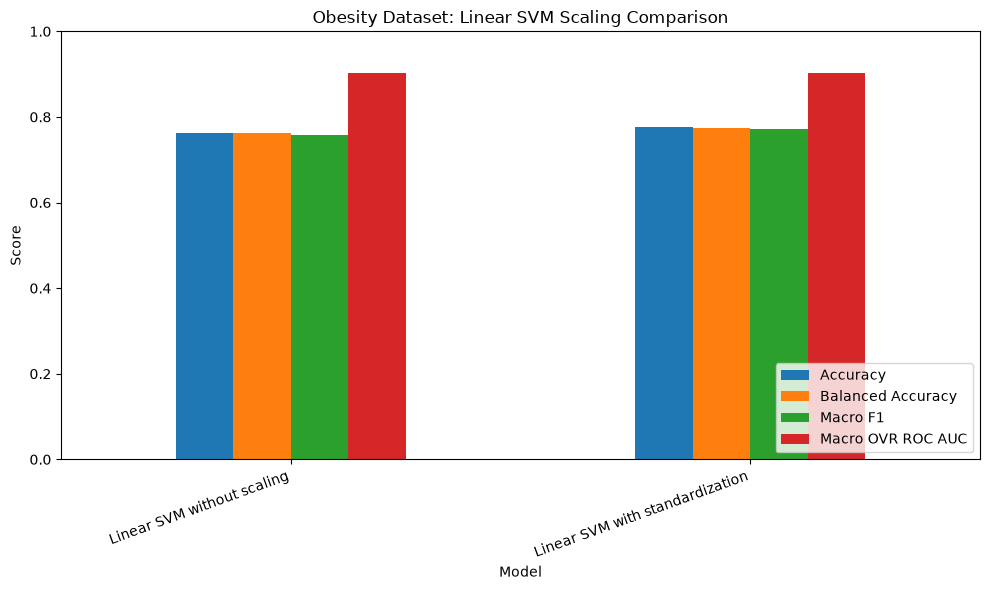

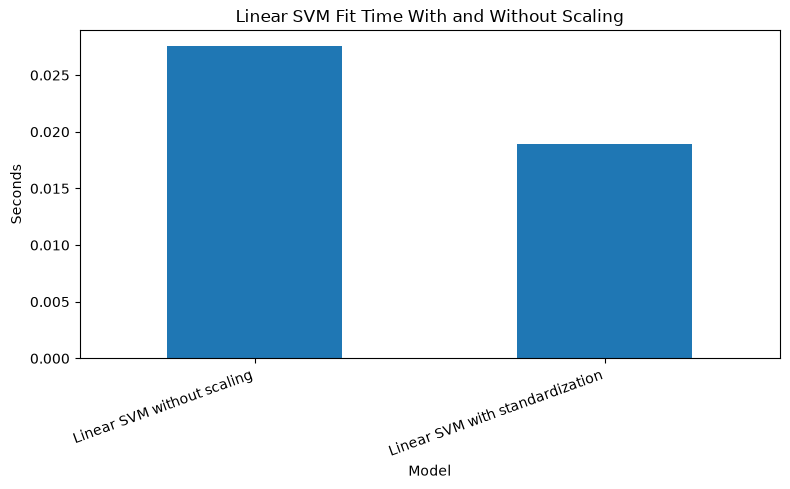

In [23]:
linear_svm_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Obesity Dataset: Linear SVM Scaling Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

linear_svm_results_df.set_index("Model")[
    ["Fit Time Seconds"]
].plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Linear SVM Fit Time With and Without Scaling")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- The **first plot** shows that **standardization** improved the linear SVM performance.

- The **second plot** compares **fit time**
    - The **standardized** model was slightly **faster** in this execution. 


- The stronger **takeaway** is the performance improvement: **standardization** increased **macro F1 from 0.757964 to 0.771217**

#### [Dataset 2] | *8- Compare SVM regularization parameter C*

In [24]:
c_results = []
c_predictions = {}
c_scores = {}
c_fitted_models = {}

for c_value in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    model_name = f"Linear SVM with C={c_value}"
    
    svm_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(
                C=c_value,
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=42
            ))
        ]
    )
    
    metrics, predictions, scores, fitted_model = evaluate_svm_model(
        model_name,
        svm_model,
        X_train,
        X_test
    )
    
    svm_step = fitted_model.named_steps["svm"]
    coefficient_norms = np.linalg.norm(svm_step.coef_, axis=1)
    margin_proxy = 1 / coefficient_norms
    
    metrics["Mean Coefficient Norm"] = coefficient_norms.mean()
    metrics["Mean Margin Proxy"] = margin_proxy.mean()
    metrics["Iterations"] = int(svm_step.n_iter_)
    
    c_results.append(metrics)
    c_predictions[model_name] = predictions
    c_scores[model_name] = scores
    c_fitted_models[model_name] = fitted_model

c_results_df = pd.DataFrame(c_results)

display(c_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Fit Time Seconds,Mean Coefficient Norm,Mean Margin Proxy,Iterations
0,Linear SVM with C=0.0001,0.567376,0.563544,0.509602,0.513318,0.875578,0.009947,0.100356,10.805879,4
1,Linear SVM with C=0.001,0.609929,0.606913,0.559862,0.563667,0.891754,0.009815,0.287571,3.743895,5
2,Linear SVM with C=0.01,0.699764,0.699079,0.680648,0.681836,0.901017,0.013051,0.646944,1.859911,6
3,Linear SVM with C=0.1,0.756501,0.755659,0.748399,0.748987,0.901989,0.014293,1.159661,1.349379,9
4,Linear SVM with C=1,0.775414,0.774361,0.771217,0.770897,0.902081,0.020386,1.862922,1.178434,32
5,Linear SVM with C=10,0.784870,0.783974,0.781611,0.780900,0.901993,0.030138,2.702393,1.124462,273



- The **best linear SVM by macro F1** was `C=10`.

- The `C` results show the regularization **trade-off clearly**:
    - Smaller `C` values produced larger margin proxies but weaker classification performance. 
    - Larger `C` values reduced the margin proxy but improved classification, meaning the model focused more on fitting the training data correctly.

#### [Dataset 2] | *9- Visualize effect of C*

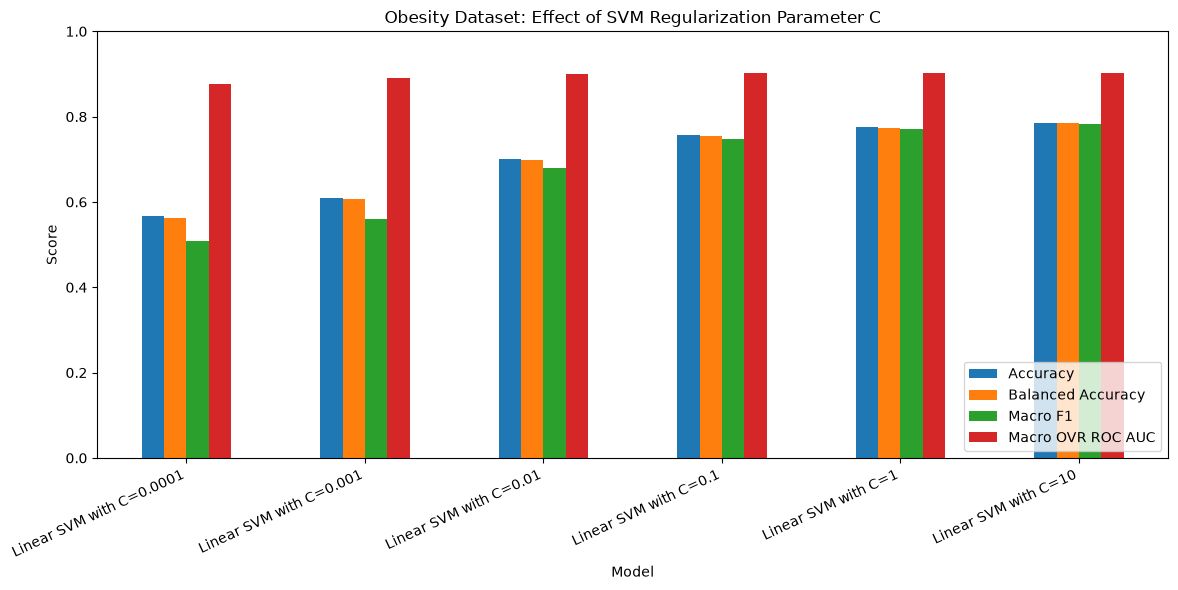

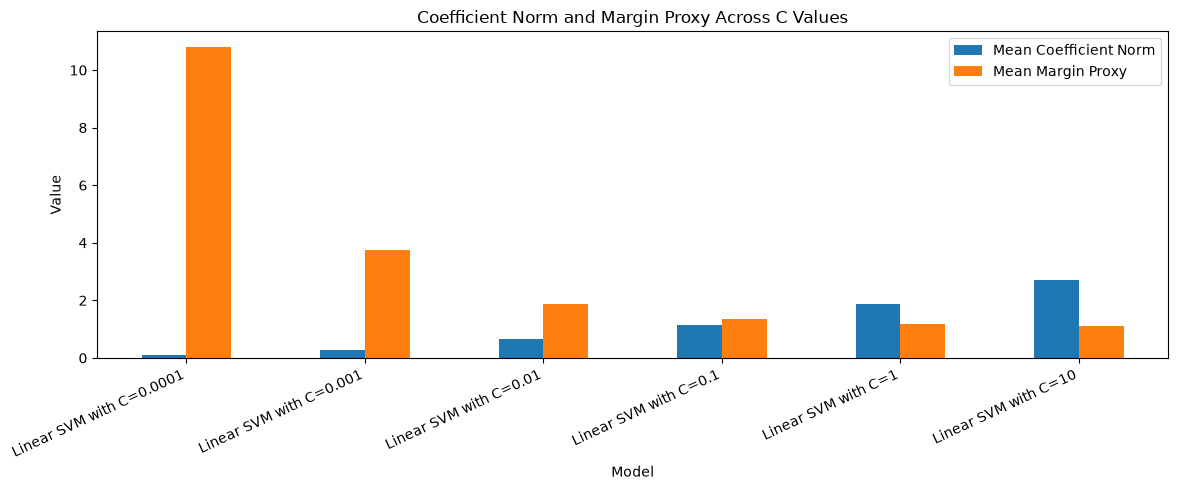

In [25]:
c_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Obesity Dataset: Effect of SVM Regularization Parameter C")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

c_results_df.set_index("Model")[
    ["Mean Coefficient Norm", "Mean Margin Proxy"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Coefficient Norm and Margin Proxy Across C Values")
plt.ylabel("Value")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- The **first plot** shows that larger `C` values improved the **linear SVM**’s classification performance.

- The **second plot** shows the margin trade-off
    - The smallest `C` value had the largest margin proxy, while the largest `C` value had the smallest margin proxy. 

- This matches the Week 5 explanation: smaller `C` values favor a wider margin, while larger `C` values focus more on correctly classifying points.

#### [Dataset 2] | *10- Define kernel SVM evaluation function*

In [26]:
def evaluate_kernel_svm(model_name, kernel, c_value=1.0, degree=3, gamma="scale"):
    kernel_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel=kernel,
                C=c_value,
                degree=degree,
                gamma=gamma,
                class_weight="balanced",
                decision_function_shape="ovr",
                random_state=42
            ))
        ]
    )
    
    start_time = time.time()
    
    kernel_model.fit(X_train, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = kernel_model.predict(X_test)
    decision_scores = kernel_model.decision_function(X_test)
    
    svm_step = kernel_model.named_steps["svm"]
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro F1": f1_score(y_test, predictions, average="macro"),
        "Weighted F1": f1_score(y_test, predictions, average="weighted"),
        "Macro OVR ROC AUC": macro_ovr_auc_from_scores(
            y_test,
            decision_scores,
            svm_step.classes_
        ),
        "Support Vectors": int(svm_step.n_support_.sum()),
        "Fit Time Seconds": fit_time
    }
    
    for class_label, support_count in zip(
        svm_step.classes_,
        svm_step.n_support_
    ):
        metrics[f"{class_label} SVs"] = int(support_count)
    
    return metrics, predictions, decision_scores, kernel_model

- This **helper** function **trains kernel SVM models and reports both performance metrics and support-vector counts**.

- The **support-vector count** is important because **support vector**s are the observations closest to the decision boundary
    - These are the points that most directly define the **margin** and **influence** the **separating boundary**

#### [Dataset 2] | *11- Compare linear, polynomial, and RBF kernels*

In [27]:
kernel_specs = [
    ("Kernel SVM: linear kernel", "linear", 1.0, 3, "scale"),
    ("Kernel SVM: polynomial degree 2", "poly", 1.0, 2, "scale"),
    ("Kernel SVM: RBF kernel", "rbf", 1.0, 3, "scale")
]

kernel_results = []
kernel_predictions = {}
kernel_scores = {}
kernel_fitted_models = {}

for model_name, kernel_name, c_value, degree, gamma in kernel_specs:
    metrics, predictions, scores, fitted_model = evaluate_kernel_svm(
        model_name=model_name,
        kernel=kernel_name,
        c_value=c_value,
        degree=degree,
        gamma=gamma
    )
    
    kernel_results.append(metrics)
    kernel_predictions[model_name] = predictions
    kernel_scores[model_name] = scores
    kernel_fitted_models[model_name] = fitted_model

kernel_results_df = pd.DataFrame(kernel_results)

display(kernel_results_df)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Support Vectors,Fit Time Seconds,Insufficient_Weight SVs,Normal_Weight SVs,Obesity_Type_I SVs,Obesity_Type_II SVs,Obesity_Type_III SVs,Overweight_Level_I SVs,Overweight_Level_II SVs
0,Kernel SVM: linear kernel,0.950355,0.949890,0.949128,0.950162,0.989724,561,0.038399,64,110,101,39,7,120,120
1,Kernel SVM: polynomial degree 2,0.749409,0.745235,0.743266,0.745866,0.923458,1169,0.036361,125,208,238,145,65,198,190
2,Kernel SVM: RBF kernel,0.841608,0.838639,0.839738,0.843111,0.957982,1088,0.035191,129,219,218,99,35,196,192



- The **linear kernel** performed best by every major metric.

- The **polynomial** and **RBF kernels** did not improve performance. 

    - This suggests that the obesity categories in this preprocessed feature space are already strongly separable with a linear boundary, especially because `Weight`, `Height`, and related encoded features carry strong information.

- The **linear kernel** also used fewer **support vectors** than the **polynomial** and **RBF kernels**, suggesting a **cleaner separating** structure.

#### [Dataset 2] | *12- Visualize kernel SVM comparison*

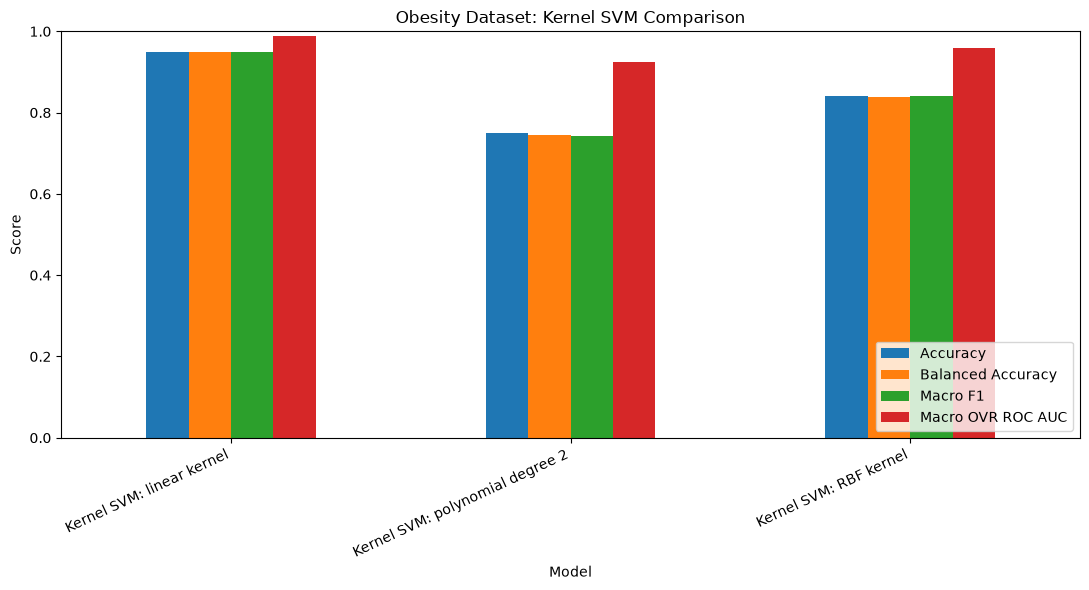

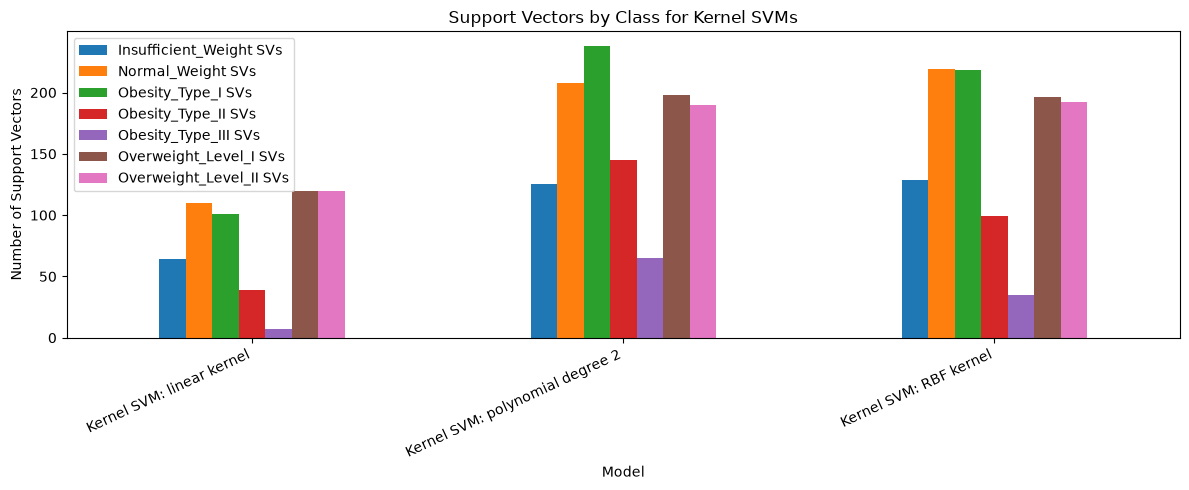

In [28]:
kernel_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "Macro F1", "Macro OVR ROC AUC"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Obesity Dataset: Kernel SVM Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

support_vector_columns = [
    column for column in kernel_results_df.columns
    if column.endswith("SVs")
]

kernel_results_df.set_index("Model")[support_vector_columns].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Support Vectors by Class for Kernel SVMs")
plt.ylabel("Number of Support Vectors")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- The **kernel comparison plot** shows that the **linear kernel** clearly performed best.

- The **support-vector plot** shows that the **linear kernel** needed fewer total support vectors than the **polynomial** and **RBF kernels**. 

    - The `Obesity_Type_III` class had very few support vectors under the **linear kernel**, which suggests that this class was relatively easy to separate.

- This matches the classification results from earlier weeks, where `Obesity_Type_III` was usually one of the easiest classes to identify.

#### [Dataset 2] | *13- Final model comparison*

In [29]:
best_c_model_name = c_results_df.loc[
    c_results_df["Macro F1"].idxmax(),
    "Model"
]

best_c_row = c_results_df[
    c_results_df["Model"] == best_c_model_name
].copy()

final_comparison = pd.concat([
    linear_svm_results_df,
    best_c_row[[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1",
        "Macro OVR ROC AUC",
        "Fit Time Seconds"
    ]],
    kernel_results_df[[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1",
        "Macro OVR ROC AUC",
        "Fit Time Seconds"
    ]]
], ignore_index=True)

display(final_comparison)

,Model,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Macro OVR ROC AUC,Fit Time Seconds
0,Linear SVM without scaling,0.763593,0.762809,0.757964,0.757963,0.901662,0.027575
1,Linear SVM with standardization,0.775414,0.774361,0.771217,0.770897,0.902081,0.018931
2,Linear SVM with C=10,0.784870,0.783974,0.781611,0.780900,0.901993,0.030138
3,Kernel SVM: linear kernel,0.950355,0.949890,0.949128,0.950162,0.989724,0.038399
4,Kernel SVM: polynomial degree 2,0.749409,0.745235,0.743266,0.745866,0.923458,0.036361
5,Kernel SVM: RBF kernel,0.841608,0.838639,0.839738,0.843111,0.957982,0.035191


- The best model was the **kernel SVM with a linear kernel**.

- This is an important result:
    - The **SVM kernel trick** allows **nonlinear** boundaries, but the best model here was **still linear**. 
    - That suggests the obesity classes are strongly separable using a **linear decision boundary after scaling**.

#### [Dataset 2] | *14- Classification report for best SVM model*

In [30]:
all_predictions = {}
all_predictions.update(linear_svm_predictions)
all_predictions.update(c_predictions)
all_predictions.update(kernel_predictions)

all_metrics = pd.concat([
    linear_svm_results_df,
    c_results_df,
    kernel_results_df
], ignore_index=True, sort=False)

best_model_name = all_metrics.loc[
    all_metrics["Macro F1"].idxmax(),
    "Model"
]

best_predictions = all_predictions[best_model_name]

print("Best SVM model by Macro F1:", best_model_name)

print(classification_report(
    y_test,
    best_predictions,
    digits=3,
    zero_division=0
))

labels = sorted(y_test.unique())

best_confusion = pd.DataFrame(
    confusion_matrix(
        y_test,
        best_predictions,
        labels=labels
    ),
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

display(best_confusion)

Best SVM model by Macro F1: Kernel SVM: linear kernel
                     precision    recall  f1-score   support

Insufficient_Weight      0.947     1.000     0.973        54
      Normal_Weight      0.926     0.862     0.893        58
     Obesity_Type_I      0.971     0.957     0.964        70
    Obesity_Type_II      0.967     0.983     0.975        60
   Obesity_Type_III      1.000     0.985     0.992        65
 Overweight_Level_I      0.883     0.914     0.898        58
Overweight_Level_II      0.948     0.948     0.948        58

           accuracy                          0.950       423
          macro avg      0.949     0.950     0.949       423
       weighted avg      0.951     0.950     0.950       423



,Predicted Insufficient_Weight,Predicted Normal_Weight,Predicted Obesity_Type_I,Predicted Obesity_Type_II,Predicted Obesity_Type_III,Predicted Overweight_Level_I,Predicted Overweight_Level_II
Actual Insufficient_Weight,54,0,0,0,0,0,0
Actual Normal_Weight,3,50,0,0,0,5,0
Actual Obesity_Type_I,0,0,67,1,0,0,2
Actual Obesity_Type_II,0,0,1,59,0,0,0
Actual Obesity_Type_III,0,0,0,1,64,0,0
Actual Overweight_Level_I,0,4,0,0,0,53,1
Actual Overweight_Level_II,0,0,1,0,0,2,55


- The **best SVM model by macro F1** was:
    - **Kernel SVM: linear kernel**

- The model performed very strongly across all classes
    - **Insufficient_Weight** had perfect **recall**
    - **Obesity_Type_III** had almost perfect performance. 
    - Most mistakes happened between neighboring categories, such as **Normal_Weight** and **Overweight_Level_I**, or **Obesity_Type_I** and **Obesity_Type_II**.

    - This makes sense because **adjacent obesity categories** are naturally harder to separate than extreme categories.

#### [Dataset 2] | *15- Summary*

- **Standardization** improved the **linear SVM** compared with the **unscaled linear SVM**

- Increasing `C` improved the **linear SVM**’s classification performance, while smaller `C` values produced **larger margin proxies**.

- The strongest overall model was the **SVM with a linear kernel**, reaching **macro F1 of 0.949128** 

- The **polynomial** and **RBF kernels** did not outperform the **linear kernel**, which suggests that the obesity classes were already well separated in the standardized feature space.

- The **main takeaway** is that **SVMs** are very effective for this dataset, and the **linear decision boundary** was stronger than the **nonlinear** kernel alternatives in this execution.

## Dataset 3: Cervical Cancer

#### [Dataset 3] | *1- Load preprocessed cervical cancer dataset*

In [31]:
cervical_path = "cervical_cancer_preprocessed_wk1.csv"


df_cervical_model = pd.read_csv(cervical_path)

print("Dataset shape:", df_cervical_model.shape)
display(df_cervical_model.head())

target = "Biopsy"

class_counts = df_cervical_model[target].value_counts().sort_index()
class_percent = (class_counts / len(df_cervical_model) * 100).round(2)

class_summary = pd.DataFrame({
    "Class Count": class_counts.astype(int),
    "Percent": class_percent
})

display(class_summary)

Dataset shape: (858, 62)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:pelvic inflammatory disease_missing,STDs:genital herpes_missing,STDs:molluscum contagiosum_missing,STDs:AIDS_missing,STDs:HIV_missing,STDs:Hepatitis B_missing,STDs:HPV_missing,STDs: Time since first diagnosis_missing,STDs: Time since last diagnosis_missing,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
2,34,1.0,17.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,1,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,0,0,0,0,0,0,0,1,1,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,0,0,0,0,0,0,0,1,1,0


,Class Count,Percent
Biopsy,,
0,803,93.59
1,55,6.41


- This is a **highly imbalanced binary classification problem**
    - Only **55** observations are biopsy-positive
    - Therefore, accuracy alone is not enough. Balanced accuracy, recall, F1, ROC AUC, and average precision are more useful for evaluating model performance

#### [Dataset 3] | *2- Train-test split*

In [32]:
X = df_cervical_model.drop(columns=[target])
y = df_cervical_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

display(y_train.value_counts().sort_index().to_frame("Train Class Count"))
display(y_test.value_counts().sort_index().to_frame("Test Class Count"))

Training shape: (686, 61)
Testing shape: (172, 61)


,Train Class Count
Biopsy,
0,642
1,44


,Test Class Count
Biopsy,
0,161
1,11


- The data was **split** into training and testing sets using **stratification**

- The executed split was:

| Split | Shape |
|---|---:|
| Training | (686, 61) |
| Testing | (172, 61) |

- The **training target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 642 |
| 1 | 44 |

- The **testing target distribution** was:

| Class | Count |
|---:|---:|
| 0 | 161 |
| 1 | 11 |

- **Stratification** is important because the **positive biopsy class is rare**
    - It keeps the **minority class represented** in both the training and test sets.

#### [Dataset 3] | *3- Investigate feature scales*

In [33]:
scale_summary = pd.DataFrame({
    "Feature": X.columns,
    "Minimum": X.min().values,
    "Maximum": X.max().values,
    "Mean": X.mean().values,
    "Std": X.std().values
})

scale_summary["Range"] = scale_summary["Maximum"] - scale_summary["Minimum"]

display(
    scale_summary
    .sort_values("Range", ascending=False)
    .head(12)
)

,Feature,Minimum,Maximum,Mean,Std,Range
0,Age,13.0,84.0,26.820513,8.497948,71.0
6,Smokes (packs/year),0.0,37.0,0.446278,2.210351,37.0
5,Smokes (years),0.0,37.0,1.201241,4.060623,37.0
8,Hormonal Contraceptives (years),0.0,30.0,2.035331,3.567040,30.0
1,Number of sexual partners,1.0,28.0,2.511655,1.644759,27.0
2,First sexual intercourse,10.0,32.0,16.995338,2.791883,22.0
26,STDs: Time since first diagnosis,1.0,22.0,4.177156,1.785156,21.0
27,STDs: Time since last diagnosis,1.0,22.0,3.233100,1.818927,21.0
10,IUD (years),0.0,19.0,0.444604,1.814218,19.0
3,Num of pregnancies,0.0,11.0,2.257576,1.400981,11.0



- This matters for **SVMs** because:
    -  **SVMs** depend on **distances**, **margins**, and **decision boundaries**.
    - If one feature has a much larger scale, such as `Age`, it can dominate the geometry of the model. 
    - Therefore, feature **scaling** is important before using **SVMs**.

#### [Dataset 3] | *4- Visualize feature ranges*

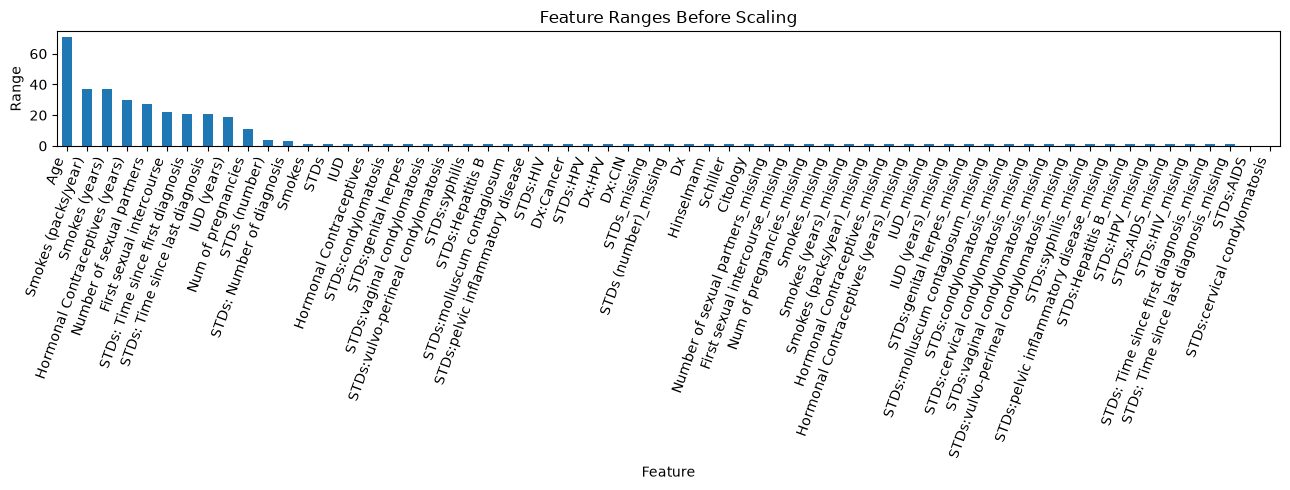

In [34]:
scale_summary.sort_values("Range", ascending=False).plot(
    x="Feature",
    y="Range",
    kind="bar",
    figsize=(13, 5),
    legend=False
)

plt.title("Feature Ranges Before Scaling")
plt.xlabel("Feature")
plt.ylabel("Range")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

- The **feature-range plot** shows that the **cervical cancer predictors are not on the same scale**.

    - `Age`, **smoking-related variables, hormonal contraceptive duration, and sexual-history variables** have much larger **numeric** ranges than **binary** variables such as `Schiller`, `Hinselmann`, `Citology`, or missingness indicators.

- **SVMs** should generally be trained after **feature scaling** because the margin depends on feature-space geometry

#### [Dataset 3] | *5- Define evaluation helper function*

In [38]:
def evaluate_svm_model(model_name, model, X_train_data, X_test_data):
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = model.predict(X_test_data)
    decision_scores = model.decision_function(X_test_data)
    
    svm_step = list(model.named_steps.values())[-1]
    classes = svm_step.classes_
    
    if decision_scores.ndim > 1:
        positive_index = list(classes).index(1)
        positive_scores = decision_scores[:, positive_index]
    else:
        positive_scores = decision_scores
        
        if classes[1] != 1:
            positive_scores = -positive_scores
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, positive_scores),
        "Average Precision": average_precision_score(y_test, positive_scores),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, positive_scores, model

- This cell defines the **helper** function used to **evaluate SVM models**.

    - **SVMs** do not **naturally produce probabilities** in the same way **logistic regression** does. 
    - Instead, they produce **decision scores**. These scores are used to calculate **ROC AUC and average precision**.

- Because this is an **imbalanced binary classification problem**, **F1, recall, ROC AUC, and average precision** are especially important.

#### [Dataset 3] | *6- Compare linear SVM with and without standardization*

In [39]:
linear_svm_models = {
    "Linear SVM without scaling": Pipeline(
        steps=[
            ("svm", LinearSVC(
                C=1.0,
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=42
            ))
        ]
    ),
    "Linear SVM with standardization": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(
                C=1.0,
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=42
            ))
        ]
    )
}

linear_svm_results = []
linear_svm_predictions = {}
linear_svm_scores = {}
linear_svm_fitted_models = {}

for model_name, model in linear_svm_models.items():
    metrics, predictions, scores, fitted_model = evaluate_svm_model(
        model_name,
        model,
        X_train,
        X_test
    )
    
    linear_svm_results.append(metrics)
    linear_svm_predictions[model_name] = predictions
    linear_svm_scores[model_name] = scores
    linear_svm_fitted_models[model_name] = fitted_model

linear_svm_results_df = pd.DataFrame(linear_svm_results)

display(linear_svm_results_df)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Fit Time Seconds
0,Linear SVM without scaling,0.953488,0.890457,0.6,0.818182,0.692308,0.909091,0.530626,0.005464
1,Linear SVM with standardization,0.953488,0.890457,0.6,0.818182,0.692308,0.919255,0.530558,0.009369


- The **class-prediction metrics** were the same for both models. However, **standardization** improved **ROC AUC from 0.909091 to 0.919255**.

- **SVMs** are sensitive to feature scale. In this execution, scaling did not change the threshold-based predictions, but it improved the ranking quality of the **decision scores**

#### [Dataset 3] | *7- Visualize linear SVM scaling comparison*

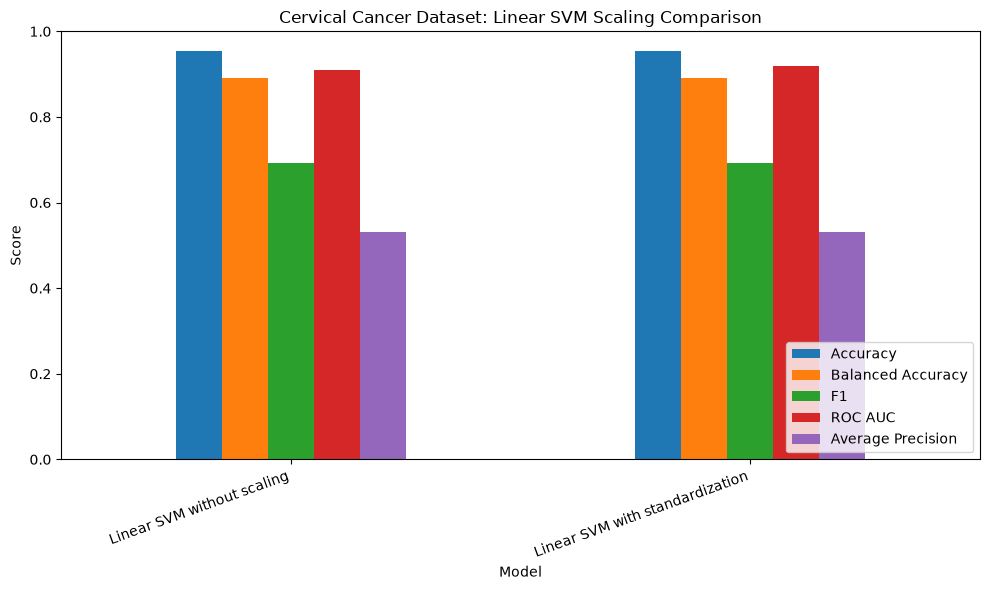

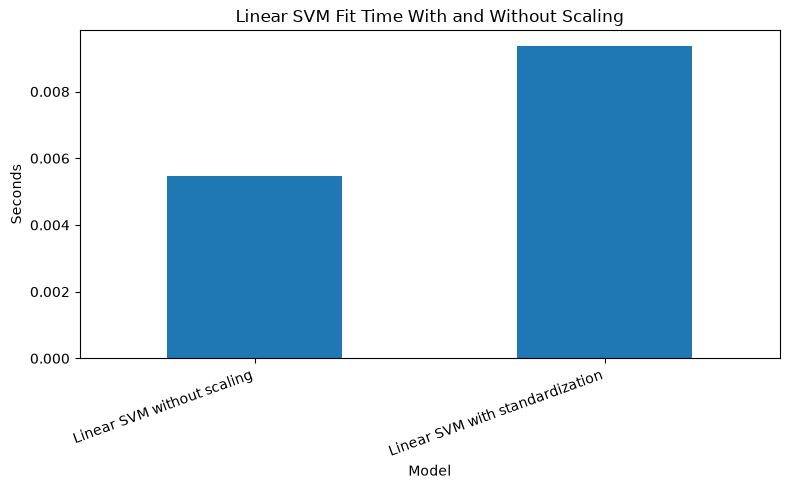

In [40]:
linear_svm_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cervical Cancer Dataset: Linear SVM Scaling Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

linear_svm_results_df.set_index("Model")[
    ["Fit Time Seconds"]
].plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Linear SVM Fit Time With and Without Scaling")
plt.ylabel("Seconds")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

- The **first plot** shows that the **scaled** and **unscaled linear SVMs** had identical **classification** performance

- The **second plot** compares **fit time**:
    - Since the dataset is small, the fit-time difference is not very meaningful. 
    
- The more useful result is that **standardization** slightly improved **ROC AUC**, meaning it improved the **ordering** of **positive** versus **negative** biopsy cases by **decision score**.

#### [Dataset 3] | *8- Compare SVM regularization parameter C*

In [41]:
c_results = []
c_predictions = {}
c_scores = {}
c_fitted_models = {}

for c_value in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    model_name = f"Linear SVM with C={c_value}"
    
    svm_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", LinearSVC(
                C=c_value,
                class_weight="balanced",
                dual=False,
                max_iter=10000,
                random_state=42
            ))
        ]
    )
    
    metrics, predictions, scores, fitted_model = evaluate_svm_model(
        model_name,
        svm_model,
        X_train,
        X_test
    )
    
    svm_step = fitted_model.named_steps["svm"]
    coefficient_norm = float(np.linalg.norm(svm_step.coef_[0]))
    margin_proxy = 1 / coefficient_norm
    
    metrics["Coefficient Norm"] = coefficient_norm
    metrics["Margin Proxy"] = margin_proxy
    metrics["Iterations"] = int(svm_step.n_iter_)
    
    c_results.append(metrics)
    c_predictions[model_name] = predictions
    c_scores[model_name] = scores
    c_fitted_models[model_name] = fitted_model

c_results_df = pd.DataFrame(c_results)

display(c_results_df)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Fit Time Seconds,Coefficient Norm,Margin Proxy,Iterations
0,Linear SVM with C=0.0001,0.860465,0.925466,0.314286,1.000000,0.478261,0.970073,0.715284,0.005378,0.123756,8.080395,4
1,Linear SVM with C=0.001,0.959302,0.893563,0.642857,0.818182,0.720000,0.953698,0.705916,0.003647,0.305619,3.272052,5
2,Linear SVM with C=0.01,0.959302,0.893563,0.642857,0.818182,0.720000,0.945793,0.540684,0.004863,0.553865,1.805494,6
3,Linear SVM with C=0.1,0.953488,0.890457,0.600000,0.818182,0.692308,0.921513,0.524889,0.005677,0.795699,1.256756,9
4,Linear SVM with C=1,0.953488,0.890457,0.600000,0.818182,0.692308,0.919255,0.530558,0.008344,1.045729,0.956271,19
5,Linear SVM with C=10,0.953488,0.890457,0.600000,0.818182,0.692308,0.919255,0.530558,0.007133,1.104458,0.905422,13


- The **best F1 score** was achieved by `C=0.001` and `C=0.01`, both with **F1 = 0.72**. 

- The `C=0.001` model had higher **ROC AUC and average precision**, so it is the stronger choice overall.

- The **margin** pattern matches the Week 5 explanation: 

    - Smaller `C` values produced smaller coefficient norms and larger margin proxies. 
    - Larger `C` values reduced the margin proxy, meaning the model allowed a narrower margin to fit the data more strictly.

#### [Dataset 3] | *9- Visualize effect of C*

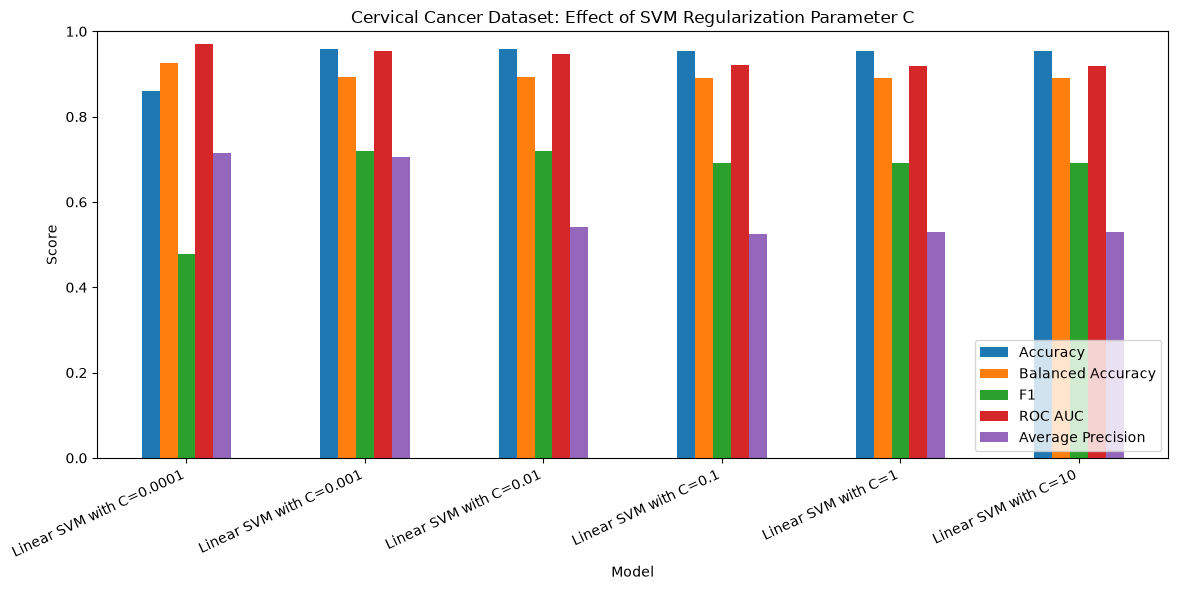

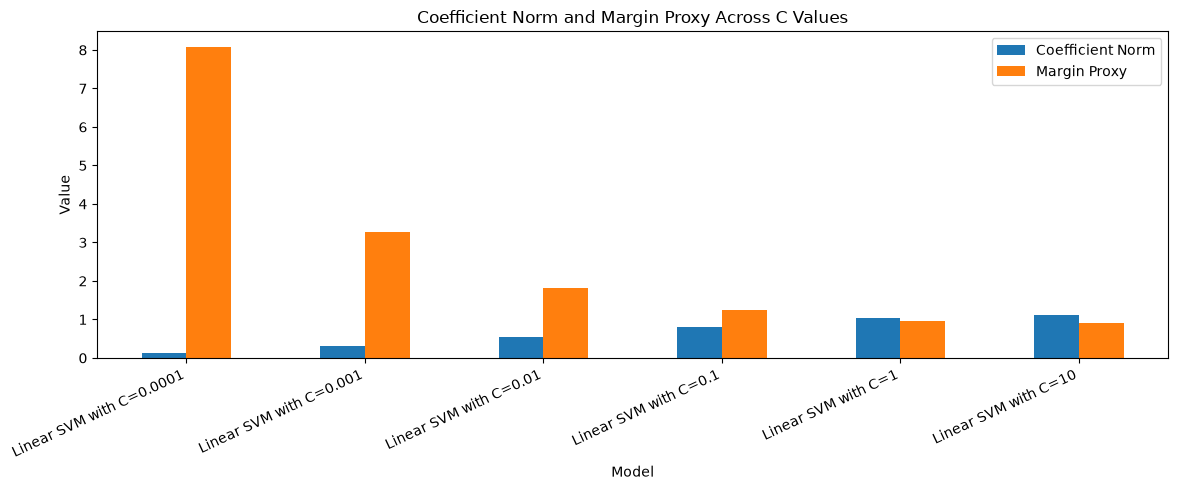

In [42]:
c_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Cervical Cancer Dataset: Effect of SVM Regularization Parameter C")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

c_results_df.set_index("Model")[
    ["Coefficient Norm", "Margin Proxy"]
].plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Coefficient Norm and Margin Proxy Across C Values")
plt.ylabel("Value")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- The **first plot** shows the **performance trade-off** across different `C` values.

- The **second plot** shows the **margin trade-off**. 
    - The smallest `C` value had the largest margin proxy, while larger `C` values had smaller margin proxies. 
    
    - Smaller `C` favors a wider margin, while larger `C` focuses more on fitting the training data correctly.

- For this dataset, `C=0.001` gave the best balance between **classification** performance and **ranking performance**.

#### [Dataset 3] | *10- Define kernel SVM evaluation function*

In [43]:
def evaluate_kernel_svm(model_name, kernel, c_value=1.0, degree=3, gamma="scale"):
    kernel_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("svm", SVC(
                kernel=kernel,
                C=c_value,
                degree=degree,
                gamma=gamma,
                class_weight="balanced",
                decision_function_shape="ovr",
                random_state=42
            ))
        ]
    )
    
    start_time = time.time()
    
    kernel_model.fit(X_train, y_train)
    
    fit_time = time.time() - start_time
    
    predictions = kernel_model.predict(X_test)
    decision_scores = kernel_model.decision_function(X_test)
    
    svm_step = kernel_model.named_steps["svm"]
    classes = svm_step.classes_
    
    if decision_scores.ndim > 1:
        positive_index = list(classes).index(1)
        positive_scores = decision_scores[:, positive_index]
    else:
        positive_scores = decision_scores
        
        if classes[1] != 1:
            positive_scores = -positive_scores
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_test, positive_scores),
        "Average Precision": average_precision_score(y_test, positive_scores),
        "Support Vectors": int(svm_step.n_support_.sum()),
        "Class 0 SVs": int(svm_step.n_support_[0]),
        "Class 1 SVs": int(svm_step.n_support_[1]),
        "Fit Time Seconds": fit_time
    }
    
    return metrics, predictions, positive_scores, kernel_model

- This **helper function trains kernel SVM models and reports both performance metrics and support-vector counts**.

- The **support-vector count** is important because support vectors are the **observations closest to the decision boundary**. 
    - These points directly influence the **margin** and the **final separating boundary**

#### [Dataset 3] | *11- Compare linear, polynomial, and RBF kernels*

In [44]:
kernel_specs = [
    ("Kernel SVM: linear kernel", "linear", 1.0, 3, "scale"),
    ("Kernel SVM: polynomial degree 2", "poly", 1.0, 2, "scale"),
    ("Kernel SVM: RBF kernel", "rbf", 1.0, 3, "scale")
]

kernel_results = []
kernel_predictions = {}
kernel_scores = {}
kernel_fitted_models = {}

for model_name, kernel_name, c_value, degree, gamma in kernel_specs:
    metrics, predictions, scores, fitted_model = evaluate_kernel_svm(
        model_name=model_name,
        kernel=kernel_name,
        c_value=c_value,
        degree=degree,
        gamma=gamma
    )
    
    kernel_results.append(metrics)
    kernel_predictions[model_name] = predictions
    kernel_scores[model_name] = scores
    kernel_fitted_models[model_name] = fitted_model

kernel_results_df = pd.DataFrame(kernel_results)

display(kernel_results_df)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Support Vectors,Class 0 SVs,Class 1 SVs,Fit Time Seconds
0,Kernel SVM: linear kernel,0.953488,0.890457,0.600000,0.818182,0.692308,0.933371,0.563699,89,70,19,0.015210
1,Kernel SVM: polynomial degree 2,0.953488,0.805759,0.636364,0.636364,0.636364,0.888199,0.620444,180,149,31,0.005546
2,Kernel SVM: RBF kernel,0.959302,0.893563,0.642857,0.818182,0.720000,0.929418,0.540136,197,159,38,0.005868


- The **kernel SVM** comparison was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision | Support Vectors | Class 0 SVs | Class 1 SVs |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| **Kernel SVM: linear kernel** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.933371 | 0.563699 | 89 | 70 | 19 |
| **Kernel SVM: polynomial degree 2** | 0.953488 | 0.805759 | 0.636364 | 0.636364 | 0.636364 | 0.888199 | 0.620444 | 180 | 149 | 31 |
| **Kernel SVM: RBF kernel** | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.929418 | 0.540136 | 197 | 159 | 38 |

- The **RBF kernel** had the best **F1 score** among the **kernel models**, with **F1 = 0.720000**. 

- The **linear kernel** had **higher ROC AUC** than the **RBF** kernel, but **lower F1**.

- The **polynomial** kernel had lower **recall** and lower **F1**, so it was **weaker** for this dataset.

- The **RBF kernel** used the most **support vectors**, which suggests a more flexible boundary. 

- This fits the Week 5 kernel idea: **nonlinear kernels** can create more complex **decision boundaries**, but they may require more **support vectors**.

#### [Dataset 3] | *12- Visualize kernel SVM comparison*

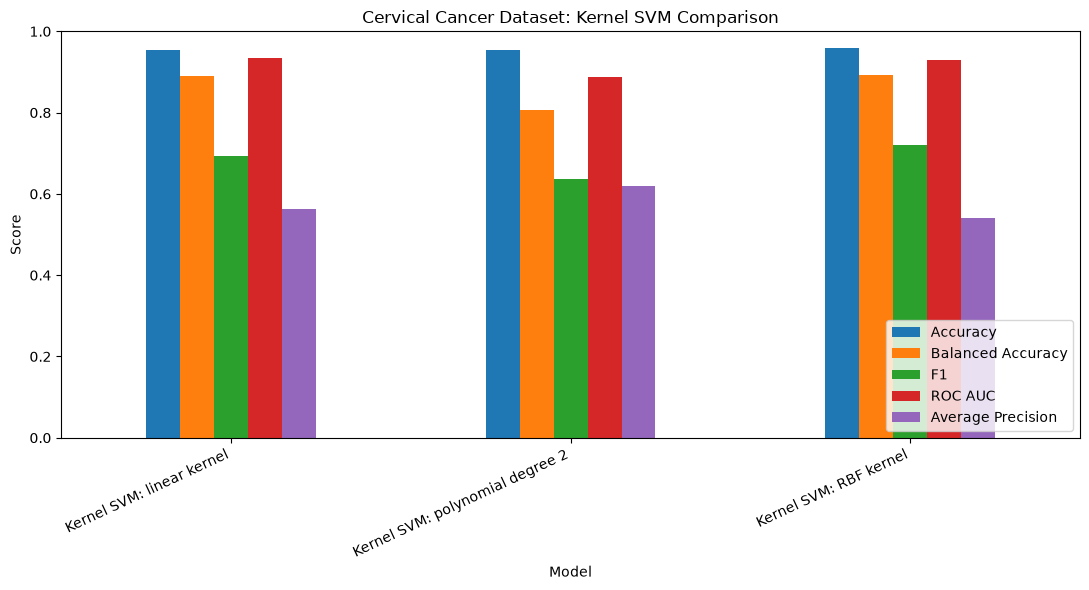

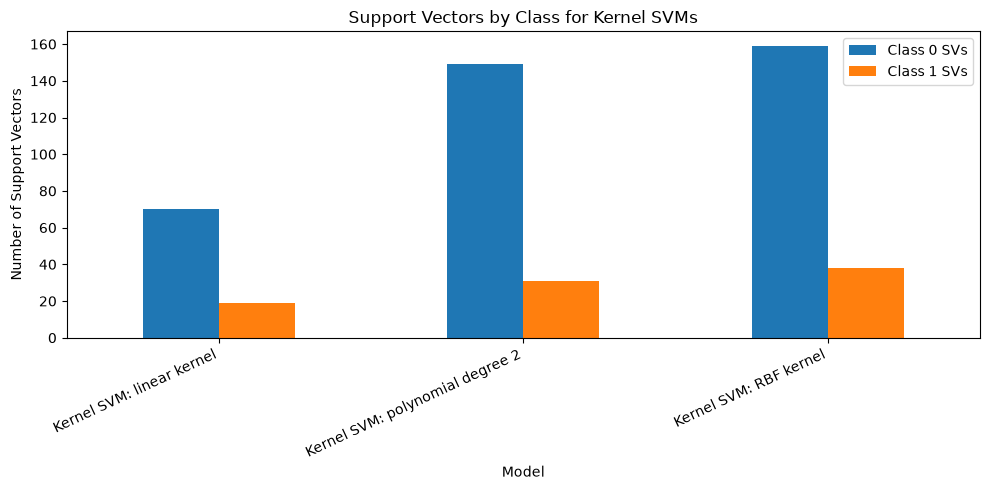

In [45]:
kernel_results_df.set_index("Model")[
    ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC", "Average Precision"]
].plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Cervical Cancer Dataset: Kernel SVM Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

kernel_results_df.set_index("Model")[
    ["Class 0 SVs", "Class 1 SVs"]
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Support Vectors by Class for Kernel SVMs")
plt.ylabel("Number of Support Vectors")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

- The **kernel comparison plot** shows that the **RBF** kernel and **linear** kernel were the **strongest kernel options**, depending on the metric.

- The **support-vector plot** shows that the **RBF** kernel used the most support vectors. 
    - This means more training observations were close enough to the **boundary** to influence the model. 
    - The **linear kernel** used fewer support vectors, suggesting a simpler separating boundary.

- For this dataset, the **RBF** kernel **improved F1**, but the **linear kernel** produced stronger ranking performance by **ROC AUC**

#### [Dataset 3] | *13- Final model comparison*

In [46]:
best_c_model_name = c_results_df.loc[
    c_results_df["F1"].idxmax(),
    "Model"
]

best_c_row = c_results_df[
    c_results_df["Model"] == best_c_model_name
].copy()

final_comparison = pd.concat([
    linear_svm_results_df,
    best_c_row[[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "Average Precision",
        "Fit Time Seconds"
    ]],
    kernel_results_df[[
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "Average Precision",
        "Fit Time Seconds"
    ]]
], ignore_index=True)

display(final_comparison)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC,Average Precision,Fit Time Seconds
0,Linear SVM without scaling,0.953488,0.890457,0.600000,0.818182,0.692308,0.909091,0.530626,0.005464
1,Linear SVM with standardization,0.953488,0.890457,0.600000,0.818182,0.692308,0.919255,0.530558,0.009369
2,Linear SVM with C=0.001,0.959302,0.893563,0.642857,0.818182,0.720000,0.953698,0.705916,0.003647
3,Kernel SVM: linear kernel,0.953488,0.890457,0.600000,0.818182,0.692308,0.933371,0.563699,0.015210
4,Kernel SVM: polynomial degree 2,0.953488,0.805759,0.636364,0.636364,0.636364,0.888199,0.620444,0.005546
5,Kernel SVM: RBF kernel,0.959302,0.893563,0.642857,0.818182,0.720000,0.929418,0.540136,0.005868


- The **final comparison** was:

| Model | Accuracy | Balanced Accuracy | Precision | Recall | F1 | ROC AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|---:|
| **Linear SVM without scaling** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.909091 | 0.530626 |
| **Linear SVM with standardization** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.919255 | 0.530558 |
| **Linear SVM with C=0.001** | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.953698 | 0.705916 |
| **Kernel SVM: linear kernel** | 0.953488 | 0.890457 | 0.600000 | 0.818182 | 0.692308 | 0.933371 | 0.563699 |
| **Kernel SVM: polynomial degree 2** | 0.953488 | 0.805759 | 0.636364 | 0.636364 | 0.636364 | 0.888199 | 0.620444 |
| **Kernel SVM: RBF kernel** | 0.959302 | 0.893563 | 0.642857 | 0.818182 | 0.720000 | 0.929418 | 0.540136 |

- The **best F1 score** was tied between the **linear SVM** with `C=0.001` and the **RBF kernel SVM**. 

    - However, the **linear SVM** with `C=0.001` had much higher **average precision** and **ROC AUC**, so it is the **strong**est overall model.

- This result suggests that the added flexibility of the **RBF** kernel did not provide enough benefit to beat the tuned **linear SVM**

#### [Dataset 3] | *14- Classification report for best SVM model*

In [47]:
all_predictions = {}
all_predictions.update(linear_svm_predictions)
all_predictions.update(c_predictions)
all_predictions.update(kernel_predictions)

all_metrics = pd.concat([
    linear_svm_results_df,
    c_results_df,
    kernel_results_df
], ignore_index=True, sort=False)

best_model_name = all_metrics.sort_values(
    ["F1", "Average Precision"],
    ascending=False
).iloc[0]["Model"]

best_predictions = all_predictions[best_model_name]

print("Best SVM model by F1 and Average Precision:", best_model_name)

print(classification_report(
    y_test,
    best_predictions,
    digits=3,
    zero_division=0
))

best_confusion = pd.DataFrame(
    confusion_matrix(y_test, best_predictions),
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(best_confusion)

Best SVM model by F1 and Average Precision: Linear SVM with C=0.001
              precision    recall  f1-score   support

           0      0.987     0.969     0.978       161
           1      0.643     0.818     0.720        11

    accuracy                          0.959       172
   macro avg      0.815     0.894     0.849       172
weighted avg      0.965     0.959     0.962       172



,Predicted 0,Predicted 1
Actual 0,156,5
Actual 1,2,9


- The **best SVM** model by **F1 and average precision** was:
    - **Linear SVM with C=0.001**


- The model correctly identified **9 of the 11 biopsy-positive cases and missed 2 positive cases**. It also produced **5 false positives**.

- This is a strong result for an imba**lanced medical classification task

#### [Dataset 3] | *15- Summary*

- **Standardization** improved the **linear SVM’s ROC AUC**, even though the class predictions stayed the same. 

- Tuning `C` improved the model, with `C=0.001` producing the best combination of **F1, ROC AUC, and average precision**.

- The **RBF kernel** tied the tuned **linear SVM** on **F1**, but it had lower **ROC AUC** and **average precision**. 

- The **polynomial kernel** performed worse because it missed more **positive biopsy cases**.

- The main takeaway is that **SVMs** work well for this dataset, but the tuned **linear SVM** was the strongest overall. The model achieved **F1** = 0.720000 for the positive biopsy class and correctly identified **9** of the **11** biopsy-positive cases.